# PUC-Rio
## Departamento de Engenharia Elétrica
## Lista de Exercícios — Séries Temporais com MLP

---

**Estudante:** Eduardo Lucas de Faria Bentolila

**Base de dados escolhida:** Air Quality

---

> **Instruções gerais:**
> - Execute **todas** as células de configuração antes de responder.
> - Responda nas células Markdown indicadas com ` Resposta:`.
> - A maioria das questões já possuem uma implementação de código. Quando for necessário escrever um código, faça-as nas células marcadas com `# SEU CÓDIGO AQUI`.
> - Use métricas quantitativas (MSE, RMSE, MAE) sempre que pertinente.
> - Esta lista explora **duas abordagens**: (1) MLP com múltiplas variáveis de entrada e saída univariada (**MISO**); (2) MLP com saída multivariada (**MIMO**), para explorar a abordagem multivariada.

---
## Configuração do Ambiente

### Funções

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

In [2]:
class TimeSeriesDataset(Dataset):
    """Dataset PyTorch genérico para séries temporais janeladas.
    Aceita y com shape (N,) para saída univariada ou (N, H) para saída multivariada.
    """
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        y_t = torch.tensor(y, dtype=torch.float32)
        self.y = y_t.unsqueeze(1) if y_t.dim() == 1 else y_t  # (N,1) ou (N,H)

    def __getitem__(self, i): return self.X[i], self.y[i]
    def __len__(self):        return len(self.X)

In [3]:
class MLP(nn.Module):
    """
    Rede Neural MLP configurável.
    Versão relativamente diferente ao apresentado em sala de aula. Neste, é feito uso
    artefato de um modelo "sequential", simplificando a implementação.
    Parâmetros
    ----------
    n_input      : int  — dimensão da entrada
    hidden_layers: list — neurônios por camada oculta, ex: [64, 32]
    n_output     : int  — dimensão da saída (1 para MISO; n_vars para MIMO)
    activation   : str  — 'relu', 'sigmoid' ou 'tanh'
    """
    _acts = {'relu': nn.ReLU, 'sigmoid': nn.Sigmoid, 'tanh': nn.Tanh}

    def __init__(self, n_input=10, hidden_layers=[64], n_output=1, activation='relu'):
        super().__init__()
        act_cls = self._acts[activation]
        layers, in_dim = [], n_input
        for h in hidden_layers:
            layers += [nn.Linear(in_dim, h), act_cls()]
            in_dim = h
        layers.append(nn.Linear(in_dim, n_output))
        self.net = nn.Sequential(*layers)

    def forward(self, x): return self.net(x)

In [4]:
def make_windows_univariate(series, window_size, horizon=1):
    """
    Janela deslizante para série 1-D (abordagem univariada).

    Retorna
    -------
    X : (N, window_size)
    y : (N,) se horizon==1  |  (N, horizon) se horizon>1
    """
    X, y = [], []
    for i in range(len(series) - window_size - horizon + 1):
        X.append(series[i : i + window_size])
        chunk = series[i + window_size : i + window_size + horizon]
        y.append(chunk[0] if horizon == 1 else chunk)
    return np.array(X), np.array(y)


def make_windows_multivariate(df_scaled, target_col, feature_cols,
                               window_size, horizon=1, mode='MISO'):
    """
    Janela deslizante para dados multivariados.

    Parâmetros
    ----------
    df_scaled   : pd.DataFrame normalizado
    target_col  : str   — coluna alvo
    feature_cols: list  — colunas usadas como features (inclui target_col)
    window_size : int
    horizon     : int
    mode        : 'MISO' — saída = próximo(s) valor(es) do target_col
                  'MIMO' — saída = próximos valores de TODAS as feature_cols

    Retorna
    -------
    X : (N, window_size * n_features)
    y : (N,) ou (N, horizon)          para MISO
        (N, n_features)               para MIMO com horizon==1
        (N, horizon * n_features)     para MIMO com horizon>1
    """
    data   = df_scaled[feature_cols].values     # (T, F)
    target = df_scaled[target_col].values       # (T,)
    n_feat = len(feature_cols)
    X, y   = [], []

    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i : i + window_size].ravel())          # flatten → (W*F,)
        if mode == 'MISO':
            chunk = target[i + window_size : i + window_size + horizon]
            y.append(chunk[0] if horizon == 1 else chunk)
        else:  # MIMO
            chunk = data[i + window_size : i + window_size + horizon]  # (H, F)
            y.append(chunk.ravel())                          # (H*F,)

    return np.array(X), np.array(y)

In [5]:
def train_model(model, loader, epochs=500, lr=1e-3, loss_fn=None, verbose=True):
    """Treina um modelo MLP e retorna o histórico de perda por época."""
    if loss_fn is None:
        loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history   = []
    model.train()
    for epoch in range(1, epochs + 1):
        epoch_loss = 0.0
        for Xb, yb in loader:
            optimizer.zero_grad()
            loss = loss_fn(model(Xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        history.append(epoch_loss / len(loader))
        if verbose and epoch % 100 == 0:
            print(f"Época {epoch:4d}/{epochs} | Perda: {history[-1]:.6f}")
    return history

In [6]:
def recursive_forecast_univariate(model, X_seed, horizon):
    """
    Previsão recursiva para modelo one-step univariado.
    X_seed : np.ndarray (window_size,)
    """
    model.eval()
    window, preds = X_seed.copy(), []
    with torch.no_grad():
        for _ in range(horizon):
            x_t = torch.tensor(window, dtype=torch.float32).unsqueeze(0)
            y_hat = model(x_t).item()
            preds.append(y_hat)
            window = np.roll(window, -1)
            window[-1] = y_hat
    return np.array(preds)


def recursive_forecast_multivariate(model, X_seed, horizon, window_size, n_features):
    """
    Previsão recursiva para modelo MISO multivariado.
    X_seed : np.ndarray (window_size * n_features,)  — janela inicial achatada
    Retorna apenas as previsões do target (primeira feature por convenção).
    """
    model.eval()
    window = X_seed.reshape(window_size, n_features).copy()  # (W, F)
    preds  = []
    with torch.no_grad():
        for _ in range(horizon):
            x_t   = torch.tensor(window.ravel(), dtype=torch.float32).unsqueeze(0)
            y_hat = model(x_t).item()          # previsão do target
            preds.append(y_hat)
            # Desliza a janela: descarta t mais antigo, acrescenta t+1
            new_row        = window[-1].copy()  # repete as exógenas do último passo
            new_row[0]     = y_hat              # atualiza o target (posição 0 por convenção)
            window         = np.vstack([window[1:], new_row])
    return np.array(preds)

In [7]:
def rrse_naive(y_true, y_pred):
    """
    RRSE com baseline naive: y_{t+1} ≈ y_t

    Parâmetros:
    - y_true: array com valores reais (y_{t+1})
    - y_pred: array com previsões do modelo (ŷ_{t+1})

    Retorna:
    - rrse (float)
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # garante alinhamento temporal
    if len(y_true) != len(y_pred):
        raise ValueError("y_true e y_pred devem ter o mesmo tamanho")

    num = np.sum((y_true - y_pred) ** 2)

    # denominador: erro do naive (y_t)
    # precisamos de y_t → shift de y_true
    y_t = y_true[:-1]
    y_t1 = y_true[1:]

    denom = np.sum((y_t1 - y_t) ** 2)

    if denom == 0:
        return np.nan  # ou np.inf dependendo do caso

    return np.sqrt(num / denom)

def evaluate(y_true, y_pred, label='Modelo', scaler=None, target_idx=0):
    """
    Calcula e exibe MSE, RMSE, MAE e SSE.
    Se scaler não for None, desnormaliza antes de calcular.
    target_idx: coluna do target caso y seja multivariado.
    """
    yt, yp = np.array(y_true).ravel(), np.array(y_pred).ravel()
    if scaler is not None:
        # Desnormaliza somente a coluna do target
        def inv(v):
            tmp = np.zeros((len(v), scaler.n_features_in_))
            tmp[:, target_idx] = v
            return scaler.inverse_transform(tmp)[:, target_idx]
        yt, yp = inv(yt), inv(yp)
    mse  = mean_squared_error(yt, yp)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(yt, yp)
    mape = mean_absolute_percentage_error(yt, yp)
    rrse = rrse_naive(yt, yp)
    sse  = np.sum((yt - yp) ** 2)
    print(f"[{label}]  MSE={mse:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}  SSE={sse:.2f}  MAPE={mape:.2f}  RRSE*:{rrse:.2f}")
    return mse, rmse, mae, sse

---
### Carregamento e Configuração do Dataset

Esta lista, a princípio, funciona para **qualquer série multivariada**.  
O exemplo padrão usa o dataset **Air Quality** (UCI), mas você pode substituir pela URL ou caminho de outro dataset.

Caso use outro dataset, não esqueça de configurar os seguintes itens abaixo.

**Parâmetros que você deve configurar:**

| Parâmetro | Descrição |
|---|---|
| `TARGET_COL` | Coluna a ser prevista |
| `FEATURE_COLS` | Lista de variáveis usadas como entrada (inclui `TARGET_COL`) |
| `WINDOW_SIZE` | Tamanho da janela temporal |
| `HORIZON` | Número de passos à frente para previsão multi-step |
| `TEST_SPLIT` | Proporção do conjunto de teste |

In [8]:
# ============================================================
#  CONFIGURAÇÃO — modifique conforme o dataset escolhido
# ============================================================

# --- Dataset: Air Quality (UCI) ---
# Variáveis: CO(GT), PT08.S1(CO), NMHC(GT), C6H6(GT),
#            PT08.S2(NMHC), NOx(GT), PT08.S3(NOx),
#            NO2(GT), PT08.S4(NO2), PT08.S5(O3), T, RH, AH

DATA_URL = (
    'https://archive.ics.uci.edu/ml/machine-learning-databases/'
    '00360/AirQualityUCI.zip'
)

# --- Ou use um dos datasets do repositório da disciplina ---
# DATASET_NAME = 'microclima1'
# DATA_URL = f'https://raw.githubusercontent.com/mdrs-thiago/PUC_Redes_Neurais/main/datasets/s_{DATASET_NAME}.csv'

# ============================================================
#  Parâmetros globais
# ============================================================
TARGET_COL   = 'CO(GT)'        # variável alvo
FEATURE_COLS = [               # features de entrada (inclua TARGET_COL)
    'CO(GT)', 'T', 'RH', 'C6H6(GT)', 'NOx(GT)', 'PT08.S3(NOx)'
]
WINDOW_SIZE  = 12
HORIZON      = 6
TEST_SPLIT   = 0.15
BATCH_SIZE   = 32
# ============================================================

In [9]:
# Essa parte é apenas para o airquality dataset. Se for qualquer outro, substitua pelo que for adequado para leitura do dataset.

import io, zipfile, urllib.request

resp = urllib.request.urlopen(DATA_URL)
z    = zipfile.ZipFile(io.BytesIO(resp.read()))
raw_data = pd.read_csv(
    z.open('AirQualityUCI.csv'),
    sep=';', decimal=',', parse_dates={'datetime': ['Date','Time']},
    dayfirst=True
)

raw_data.replace(-200, np.nan, inplace=True)
#raw_data.dropna(subset=FEATURE_COLS, inplace=True)
raw_data.fillna(method='ffill',inplace=True)
raw_data.reset_index(drop=True, inplace=True)

print(f"Shape após limpeza : {raw_data.shape}")
print(f"Colunas disponíveis: {raw_data.select_dtypes(include=np.number).columns.tolist()}")
raw_data[FEATURE_COLS].describe().round(2)

Shape após limpeza : (9471, 16)
Colunas disponíveis: ['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'Unnamed: 15', 'Unnamed: 16']


,CO(GT),T,RH,C6H6(GT),NOx(GT),PT08.S3(NOx)
count,9471.00,9471.00,9471.00,9471.00,9471.00,9471.00
mean,2.08,18.44,48.39,10.21,241.02,830.59
std,1.46,8.84,17.68,7.52,205.39,254.91
min,0.10,-1.90,9.20,0.10,2.00,322.00
25%,1.00,11.90,34.90,4.40,98.00,654.00
50%,1.70,17.70,48.60,8.40,176.00,803.00
75%,2.70,24.60,61.70,13.90,316.00,964.00
max,11.90,44.60,88.70,63.70,1479.00,2683.00


In [10]:
n_samples = len(raw_data)
n_test    = int(n_samples * TEST_SPLIT)
n_train   = n_samples - n_test

scaler = MinMaxScaler()
scaler.fit(raw_data[FEATURE_COLS].values[:n_train])

scaled_values = scaler.transform(raw_data[FEATURE_COLS].values)
df_scaled = pd.DataFrame(scaled_values, columns=FEATURE_COLS)

target_idx = FEATURE_COLS.index(TARGET_COL)   # posição do target na lista de features
n_features = len(FEATURE_COLS)

print(f"Amostras totais : {n_samples}  |  Treino: {n_train}  |  Teste: {n_test}")
print(f"Features ({n_features}): {FEATURE_COLS}")
print(f"Target          : '{TARGET_COL}' (índice {target_idx})")

Amostras totais : 9471  |  Treino: 8051  |  Teste: 1420
Features (6): ['CO(GT)', 'T', 'RH', 'C6H6(GT)', 'NOx(GT)', 'PT08.S3(NOx)']
Target          : 'CO(GT)' (índice 0)


---
# Seção 1 — Pré-processamento, Análise e Transformação de Dados

---
### Q1 — Análise Exploratória da Série

Execute o código abaixo para visualizar a variável alvo. Analise e responda:

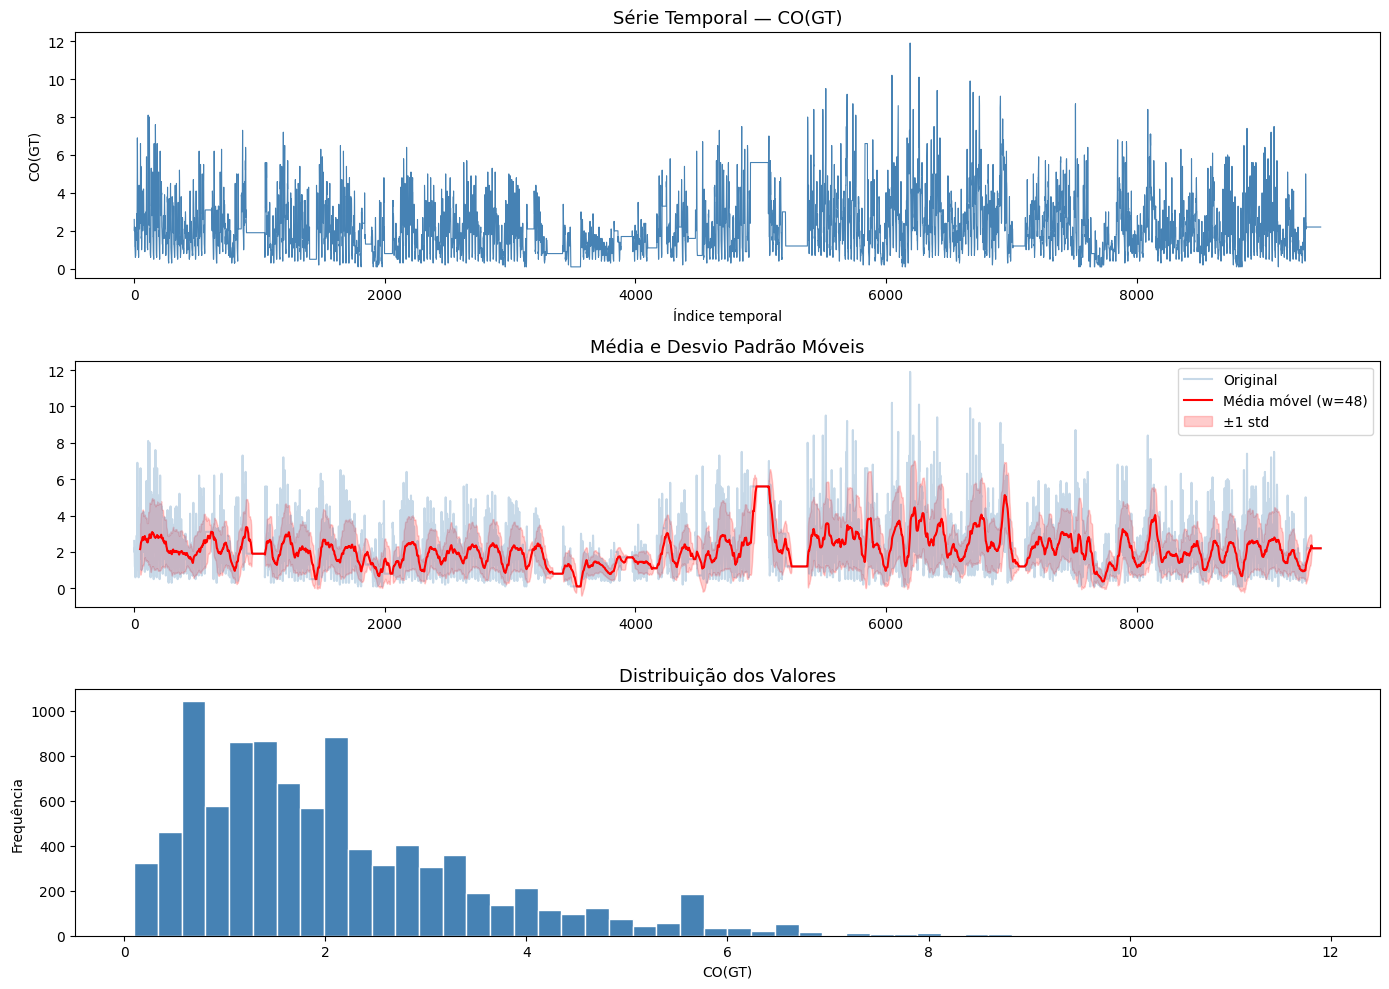

count    9471.000
mean        2.084
std         1.461
min         0.100
25%         1.000
50%         1.700
75%         2.700
max        11.900
dtype: float64


In [11]:
# --- Código fornecido ---
series_raw = raw_data[TARGET_COL].values

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(series_raw, color='steelblue', linewidth=0.8)
axes[0].set_title(f'Série Temporal — {TARGET_COL}', fontsize=13)
axes[0].set_xlabel('Índice temporal')
axes[0].set_ylabel(TARGET_COL)

win = 48
roll_mean = pd.Series(series_raw).rolling(win).mean()
roll_std  = pd.Series(series_raw).rolling(win).std()
axes[1].plot(series_raw, alpha=0.3, label='Original', color='steelblue')
axes[1].plot(roll_mean, color='red',  label=f'Média móvel (w={win})')
axes[1].fill_between(range(len(series_raw)),
                     roll_mean - roll_std, roll_mean + roll_std,
                     alpha=0.2, color='red', label='±1 std')
axes[1].set_title('Média e Desvio Padrão Móveis', fontsize=13)
axes[1].legend()

axes[2].hist(series_raw, bins=50, color='steelblue', edgecolor='white')
axes[2].set_title('Distribuição dos Valores', fontsize=13)
axes[2].set_xlabel(TARGET_COL)
axes[2].set_ylabel('Frequência')

plt.tight_layout()
plt.show()
print(pd.Series(series_raw).describe().round(3))

**Resposta Q1:**

**a) A série apresenta tendência?**
> Vemos que a série não apresenta uma tendência, seja de crescimento ou queda. Normalmente, tendência ocorrem quando há um aumento/decréscimo consistente na média da série ao longo do tempo. No entanto, a média desta série está em torno de 2.08, próximo do valor inicial e final da série, sem que apresente uma inclinação de subida/descida a longo prazo.

**b) Há indícios de sazonalidade?**
> A série aparenta se repetir em intervalos fixos, o que mostra um indício de sazonalidade. Embora o gráfico da série seja bem ruidoso, o comportamento de oscilação da curva sugere que seja cíclica, visto a natureza de dados horários. Assim, as emissões de gases ocorrem repetidamente ao longo de 24 horas, sugerindo uma sazonalidade com picos no momento de maior tráfego urbano, e vales nos momentos mais calmos da cidade.

**c) O comportamento parece estacionário?**
> Há indícios de que a série é estacionária, pois, como a média e a variância (desvio padrão ao quadrado) não variam significativamente ao longo do tempo como podemos ver no segundo gráfico, então podemos inferir que há estacionariedade. Além disso, o histograma apresenta que os valores de CO são mais presentes entre 0 e 4, o que mostra um comportamento bem definido e reforça a teoria da série ser estacionária.

---
### Q2 — Estrutura Multivariada

O código abaixo visualiza todas as variáveis disponíveis e suas relações com o target. Com base nos resultados, defina quais variáveis incluir em `FEATURE_COLS` (você pode alterar a configuração e rodar novamente).

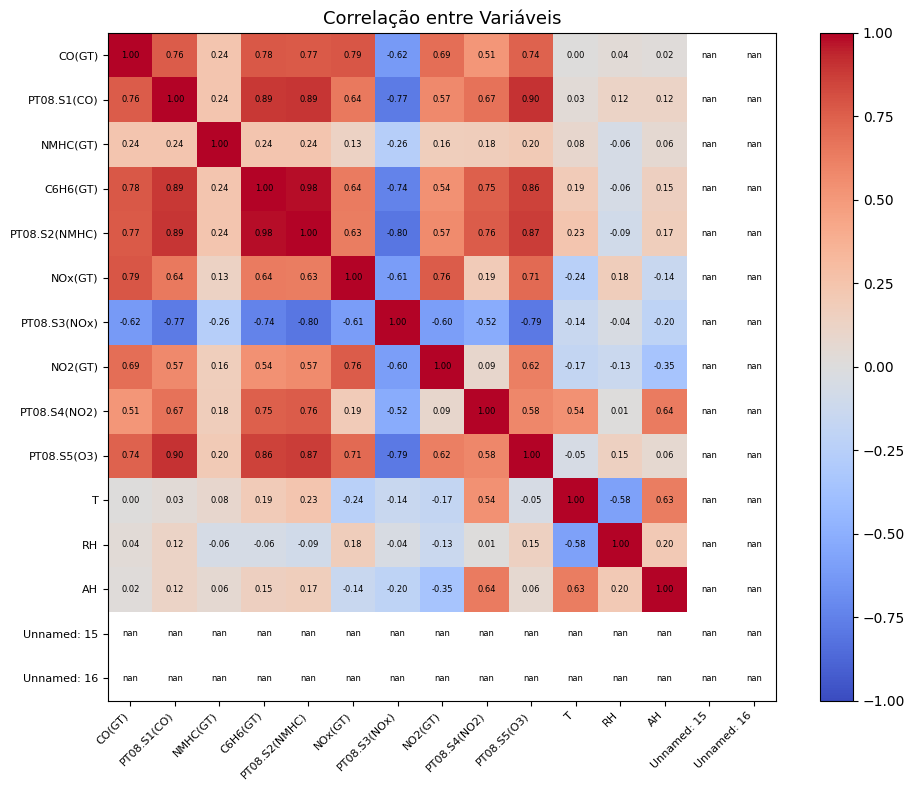


Correlação de cada variável com 'CO(GT)':
  CO(GT)                         r = +1.0000
  PT08.S1(CO)                    r = +0.7630
  NMHC(GT)                       r = +0.2385
  C6H6(GT)                       r = +0.7790
  PT08.S2(NMHC)                  r = +0.7687
  NOx(GT)                        r = +0.7879
  PT08.S3(NOx)                   r = -0.6193
  NO2(GT)                        r = +0.6885
  PT08.S4(NO2)                   r = +0.5089
  PT08.S5(O3)                    r = +0.7353
  T                              r = +0.0026
  RH                             r = +0.0390
  AH                             r = +0.0219
  Unnamed: 15                    r = +nan
  Unnamed: 16                    r = +nan

Autocorrelação de 'CO(GT)' com suas defasagens:
  lag=  1  r = +0.8685
  lag=  2  r = +0.6822
  lag=  3  r = +0.5309
  lag=  6  r = +0.2984
  lag= 12  r = +0.2404
  lag= 24  r = +0.6061


In [12]:
# --- Código fornecido: correlação e defasagens ---
num_cols = raw_data.select_dtypes(include=np.number).columns.tolist()

# Matriz de correlação
corr = raw_data[num_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(num_cols))); ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(num_cols, fontsize=8)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=6)
ax.set_title('Correlação entre Variáveis', fontsize=13)
plt.tight_layout(); plt.show()

# Correlação do target com variáveis e com defasagens do próprio target
print(f"\nCorrelação de cada variável com '{TARGET_COL}':")
for col in num_cols:
    r = raw_data[TARGET_COL].corr(raw_data[col])
    print(f"  {col:30s} r = {r:+.4f}")

print(f"\nAutocorrelação de '{TARGET_COL}' com suas defasagens:")
s = raw_data[TARGET_COL]
for lag in [1, 2, 3, 6, 12, 24]:
    print(f"  lag={lag:3d}  r = {s.corr(s.shift(lag)):+.4f}")

**Resposta Q2:**

**a) Quais variáveis têm maior correlação com o target? Elas são adequadas como features?**
> As variáveis `C6H6(GT)` (0.78), `NOx(GT)` (0.79), `PT08.S1(CO)` (0.76), `PT08.S2(NMHC)` (0.77), `PT08.S3(NOx)` (-0.77), `PT08.S5(O3)` (0.74) e `NO2(GT)` (0.69) são as que possuem maior correlação com o target. A ideia de escolher essas variáveis com correlação maior que |0.7| (com exceção do `NO2(GT)` que foi escolhido pela proximidade do valor) está relacionada com o fato de não incluirmos um excesso de variáveis que poderá atrapalhar o treinamento do modelo.

>Elas são adequadas, visto que C6H6, NOx e NO2 caminham junto com o CO, o que é comum em poluição por combustão. Além disso, as variáveis PT, são ótimos features pois são substitutos eletrônicos que verificam a presença dos gases.

>No entanto, avaliando essas variáveis e suas correlações entre si, identificamos que `C6H6(GT)` possui alta correlação com os 3 sensores com maior correlação com o target (`PT08.S1(CO)`; `PT08.S2(NMHC)`; `PT08.S5(O3)`), e portanto, para a previsão, utilizaremos uma feature para evitar redundância no treinamento do modelo, que será `C6H6(GT)`. O mesmo acontece entre `NOx(GT)` e `NO2(GT)`, e pelo mesmo motivo, manteremos a `NOx(GT)`. Além disso, carregaremos `PT08.S3(NOx)` que, além de possuir uma correlação negativa, não apresenta correlação alta o suficiente com as outras features escolhidas para que a desconsideremos do modelo, como é o caso de `PT08.S2(NMHC)` com `C6H6(GT)` que a correlação se aproxima de 1.

**b) Existe correlação com defasagens do próprio target? O que isso indica?**
> Pela autocorrelação do target, vemos que há sim correlação da própria variável, principalmente nos lags 1, 2 e 24. Isso indica que, se o ar está poluído na hora t, na hora t+1 ele terá grandes chances de também o estar, devido a alta correlação do lag 1(~ 0.87). Além disso, o lag 2 também é um indicativo de que em t+2, há uma chance boa do ar continuar poluído, dado que é uma correlação alta, mas não ao nível de 1. O lag 24, que apesar de apresentar uma correlação abaixo de 1 e 2, com os outros lags comparados, ele aparenta ser o 3° maior, isso nos leva ao indício de que existe uma sazonalidade diária, a cada 24 horas, assim como observado na questão 1, ou seja, sempre na mesma hora do dia, se o ar estiver poluído, no dia seguinte ele provavelmente também o estará.

**c) Justifique as variáveis que você incluiu em `FEATURE_COLS`.**

Dica: observe que existem valores com PT08 e GT, como PT08.S1(CO) e CO(GT). Os valores com PT indicam aqueles medidos pelos sensores, e aqueles com GT sinalizam os valores Ground Truth (i.e., a quantidade de CO no ar).
> As variáveis foram incluídas em `FEATURE_COLS` seguindo dois critérios principais:
>1. Alta Correlação e evitando Redundância: Foram incluídas as variáveis de referência Ground Truth (C6H6, NOx) e um sensor (PT08.S3), que apresentaram correlação superior a |0.7| relativo ao target, e os sensores (PT08.S1, PT08.S2, PT08.S5) foram descartados pela alta correlação existente com C6H6. O mesmo acontece com o NO2, que possui uma correlação alta com o NOx. Isso garante que o modelo aprenda com poluentes que coexistem com o CO.
>2. Contexto Ambiental: Mantivemos T (Temperatura) e RH (Umidade Relativa) pois, embora tenham baixa correlação, elas influenciam a dispersão dos gases e a resposta dos sensores (PT), ajudando o modelo a ajustar as leituras dos sensores de acordo com as condições climáticas.

---
### Q3 — Construção da Janela Temporal Multivariada

O código abaixo cria as janelas deslizantes para os dois modos usados nesta lista:

- **MISO** (*Multiple Input, Single Output*): todas as features entram na janela; a saída é apenas o próximo valor do target.
- **MIMO** (*Multiple Input, Multiple Output*): todas as features entram na janela; a saída são os próximos valores de **todas** as features.

Analise as dimensões resultantes e responda.

In [13]:
# --- Código fornecido: construção das janelas ---

# ---- UNIVARIADO (baseline) ----
series_uni = df_scaled[TARGET_COL].values
X_uni, y_uni = make_windows_univariate(series_uni, WINDOW_SIZE, horizon=1)
split_uni = n_train - WINDOW_SIZE
X_uni_tr, X_uni_te = X_uni[:split_uni], X_uni[split_uni:]
y_uni_tr, y_uni_te = y_uni[:split_uni], y_uni[split_uni:]

# ---- MISO ----
X_miso, y_miso = make_windows_multivariate(
    df_scaled, TARGET_COL, FEATURE_COLS, WINDOW_SIZE, horizon=1, mode='MISO'
)
split_mv = n_train - WINDOW_SIZE
X_miso_tr, X_miso_te = X_miso[:split_mv], X_miso[split_mv:]
y_miso_tr, y_miso_te = y_miso[:split_mv], y_miso[split_mv:]

# ---- MIMO (one-step) ----
X_mimo, y_mimo = make_windows_multivariate(
    df_scaled, TARGET_COL, FEATURE_COLS, WINDOW_SIZE, horizon=1, mode='MIMO'
)
X_mimo_tr, X_mimo_te = X_mimo[:split_mv], X_mimo[split_mv:]
y_mimo_tr, y_mimo_te = y_mimo[:split_mv], y_mimo[split_mv:]

# ---- MIMO (multi-step) ----
X_mimo_ms, y_mimo_ms = make_windows_multivariate(
    df_scaled, TARGET_COL, FEATURE_COLS, WINDOW_SIZE, horizon=HORIZON, mode='MIMO'
)
X_mimo_ms_tr, X_mimo_ms_te = X_mimo_ms[:split_mv], X_mimo_ms[split_mv:]
y_mimo_ms_tr, y_mimo_ms_te = y_mimo_ms[:split_mv], y_mimo_ms[split_mv:]

print("Resumo das dimensões:")
print(f"  Univariado   X_train: {X_uni_tr.shape}   y_train: {y_uni_tr.shape}")
print(f"  MISO         X_train: {X_miso_tr.shape}  y_train: {y_miso_tr.shape}")
print(f"  MIMO 1-step  X_train: {X_mimo_tr.shape}  y_train: {y_mimo_tr.shape}")
print(f"  MIMO {HORIZON}-step  X_train: {X_mimo_ms_tr.shape}  y_train: {y_mimo_ms_tr.shape}")
print(f"\nDimensão entrada do modelo MISO : {X_miso_tr.shape[1]}  (= {WINDOW_SIZE} passos × {n_features} features)")
print(f"Dimensão saída do modelo MIMO   : {y_mimo_tr.shape[1]}  (= 1 passo × {n_features} features)")
print(f"Dimensão saída MIMO multi-step  : {y_mimo_ms_tr.shape[1]} (= {HORIZON} passos × {n_features} features)")

Resumo das dimensões:
  Univariado   X_train: (8039, 12)   y_train: (8039,)
  MISO         X_train: (8039, 72)  y_train: (8039,)
  MIMO 1-step  X_train: (8039, 72)  y_train: (8039, 6)
  MIMO 6-step  X_train: (8039, 72)  y_train: (8039, 36)

Dimensão entrada do modelo MISO : 72  (= 12 passos × 6 features)
Dimensão saída do modelo MIMO   : 6  (= 1 passo × 6 features)
Dimensão saída MIMO multi-step  : 36 (= 6 passos × 6 features)


**Resposta Q3:**

**a) O que cada amostra de entrada representa na abordagem MISO/MIMO? Existem perdas de dados na elaboração da base de dados?**
> Cada amostra representa uma janela deslizante contendo o histórico de todas as variáveis selecionadas. Nesse caso, representa o estado das 6 features escolhidas (`CO(GT)`, `T`, `RH`, `C6H6(GT)`, `NOx(GT)`, `PT08.S3(NOx)`) durante as últimas 12 horas (WINDOW_SIZE inicial igual a 12).

> Há perdas de dados na elaborção da base, os primeiros registros do dataset são descartados porque não possuem passado suficiente para preencher a janela (`WINDOW_SIZE`), e os últimos registros são perdidos porque não possuem o futuro necessário para servir de rótulo (`HORIZON`).

**b) Por que a dimensão de entrada do MISO é `WINDOW_SIZE × n_features` e não apenas `WINDOW_SIZE`?**
> Porque, diferentemente do modelo univariado que olha apenas para o passado da própria série alvo, o modelo MISO (como o próprio nome indica -> "Multiple Input") utiliza as informações de todas as features simultaneamente para a previsão. Para que a rede neural MLP consiga processar isso, a matriz de dados (12 passos x 6 variáveis) é transformada em um único vetor de 72 posições. Isso permite que o modelo aprenda correlações cruzadas entre diferentes features ao longo do tempo para melhorar a previsão do target.

---
# Seção 2 — Avaliação de Modelos (One-Step, Recursivo, Direto)

Nesta seção, cada abordagem é testada nas versões **univariada** e **MISO**, permitindo comparar o ganho real do uso de features adicionais.

In [14]:
loader_uni  = DataLoader(TimeSeriesDataset(X_uni_tr,  y_uni_tr),  batch_size=BATCH_SIZE, shuffle=False)
loader_miso = DataLoader(TimeSeriesDataset(X_miso_tr, y_miso_tr), batch_size=BATCH_SIZE, shuffle=False)

---
### Q4 — Previsão One-Step: Univariado vs. MISO

Execute o treinamento dos dois modelos abaixo. Ambos possuem a mesma arquitetura; a diferença está **apenas na dimensão de entrada**.

In [15]:
model_uni  = MLP(n_input=WINDOW_SIZE,                hidden_layers=[64, 32], n_output=1)
model_miso = MLP(n_input=WINDOW_SIZE * n_features,   hidden_layers=[64, 32], n_output=1)

print("=== Univariado ===")
hist_uni  = train_model(model_uni,  loader_uni,  epochs=500, lr=1e-3, verbose=True)
print("\n=== MISO ===")
hist_miso = train_model(model_miso, loader_miso, epochs=500, lr=1e-3, verbose=True)

=== Univariado ===
Época  100/500 | Perda: 0.002122
Época  200/500 | Perda: 0.001854
Época  300/500 | Perda: 0.001659
Época  400/500 | Perda: 0.001499
Época  500/500 | Perda: 0.001427

=== MISO ===
Época  100/500 | Perda: 0.001952
Época  200/500 | Perda: 0.001586
Época  300/500 | Perda: 0.001344
Época  400/500 | Perda: 0.001159
Época  500/500 | Perda: 0.001057


[Univariado]  MSE=0.3784  RMSE=0.6152  MAE=0.4166  SSE=537.39  MAPE=0.26  RRSE*:0.81
[MISO      ]  MSE=0.4362  RMSE=0.6605  MAE=0.4622  SSE=619.44  MAPE=0.30  RRSE*:0.87


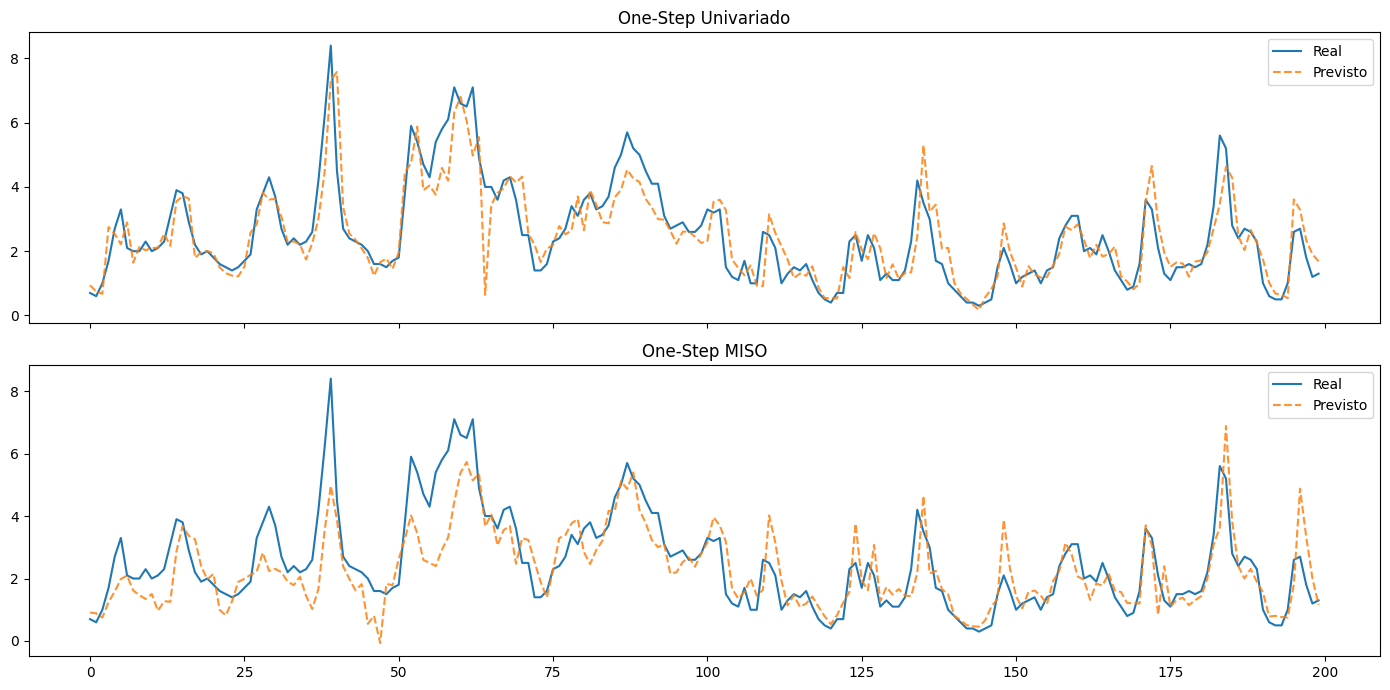

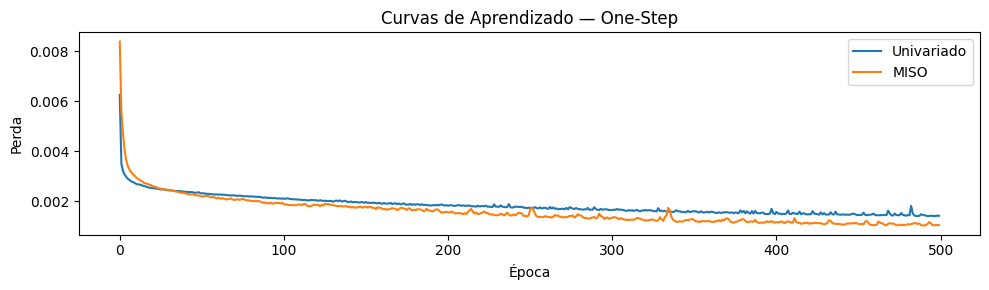

In [16]:
def predict(model, X):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(X, dtype=torch.float32)).numpy().ravel()

yp_uni  = predict(model_uni,  X_uni_te)
yp_miso = predict(model_miso, X_miso_te)

evaluate(y_uni_te,  yp_uni,  label='Univariado', scaler=scaler, target_idx=target_idx)
evaluate(y_miso_te, yp_miso, label='MISO      ', scaler=scaler, target_idx=target_idx)

# Desnormaliza para visualização
def denorm(v):
    tmp = np.zeros((len(v), n_features)); tmp[:, target_idx] = v
    return scaler.inverse_transform(tmp)[:, target_idx]

N_plot = min(200, len(y_uni_te))
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
for ax, yt, yp, title in [
    (axes[0], y_uni_te[:N_plot],  yp_uni[:N_plot],  'One-Step Univariado'),
    (axes[1], y_miso_te[:N_plot], yp_miso[:N_plot], 'One-Step MISO'),
]:
    ax.plot(denorm(yt), label='Real',     linewidth=1.5)
    ax.plot(denorm(yp), label='Previsto', linestyle='--', alpha=0.85)
    ax.set_title(title, fontsize=12)
    ax.legend()
plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 3))
plt.plot(hist_uni,  label='Univariado')
plt.plot(hist_miso, label='MISO')
plt.title('Curvas de Aprendizado — One-Step'); plt.xlabel('Época'); plt.ylabel('Perda')
plt.legend(); plt.tight_layout(); plt.show()

**Resposta Q4:**

**a) O modelo MISO apresenta desempenho melhor do que o univariado? A diferença é significativa?**
> Com base nos resultados obtidos, o modelo **Univariado** apresentou um desempenho ligeiramente superior ao MISO no conjunto de teste. O Univariado obteve `MSE=0.3784` e `RMSE=0.6152`, enquanto o MISO obteve `MSE=0.4362` e `RMSE=0.6605`. Não existe uma diferença significante em termos absolutos, mas ela é perceptível nos picos e vales dos gráficos e indicam que, para esta configuração de rede e variáveis, a adição de features exógenas (MISO) introduziu ruído ou complexidade que não resultou em ganho imediato de precisão na previsão de um passo à frente.

**b) As curvas de aprendizado diferem? O que isso sugere sobre a complexidade de cada problema?**
> Sim, as curvas diferem. A curva do modelo MISO começa com uma perda (loss) inicial mais alta e apresenta uma descida menos acentuada até um loss entre 0 e 100, mas acelera a partir disso, terminando com uma perda de treinamento menor que a do Univariado (`0.0010` vs `0.0014`). Isso sugere que o problema MISO é mais complexo, pois o modelo tem muito mais parâmetros para ajustar (entrada de dimensão 72 vs 12). O fato de o MISO ter MSE no teste mais elevado (conforme visto na letra A), sugere que ele é mais propenso ao *overfitting* devido a essa maior complexidade.

**c) Existem regiões onde o erro é maior? Os dois modelos falham nos mesmos pontos?**
> Ao observar o gráfico de predição, nota-se que ambos os modelos falham de forma semelhante em regiões de **picos e mudanças abruptas**. Quando a série real apresenta uma subida ou descida muito rápida, os modelos tendem a 'suavizar' o movimento, demorando um passo para reagir. As falhas são aproximadamente nos mesmos pontos de alta variabilidade, o que é típico de modelos que dependem fortemente do lag anterior.

**d) Quando lidamos com séries temporais, um dos grandes problemas que podemos encontrar á uma modelagem indesejada do tipo $\hat{y}(t+1) = y(t)$. Observe as métricas de avaliação obtidas, sobretudo o RRSE, e avalie o resultado obtido após o treinamento do modelo.**
> O RRSE (Relative Root Squared Error) é fundamental, pois um RRSE próximo de 1 indica que o modelo é tão bom quanto um modelo Naive ($\hat{y}(t+1) = y_t$). O modelo **Univariado obteve `RRSE = 0.81`**, o que mostra que ele é 19% melhor que o modelo Naive. Já o modelo **MISO obteve `RRSE = 0.87`**, o que é um resultado pouco relevante, pois indica que, neste teste, ele performou ligeiramente melhor do que simplesmente repetir o último valor conhecido. Isso reforça que o modelo MISO precisa de ajustes (como regularização ou seleção de features) para ser útil, enquanto o Univariado já mostra um aprendizado real da dinâmica da série.

---
### Q5 — Previsão Recursiva (Multi-Step): Univariado vs. MISO

Utilize as funções de previsão recursiva para gerar `HORIZON` passos à frente. Observe como o erro acumula em cada abordagem.

[Recursivo Univariado]  MSE=1.1996  RMSE=1.0952  MAE=0.7911  SSE=7.20  MAPE=0.43  RRSE*:1.89
[Recursivo MISO      ]  MSE=1.7826  RMSE=1.3351  MAE=0.9854  SSE=10.70  MAPE=0.49  RRSE*:2.30


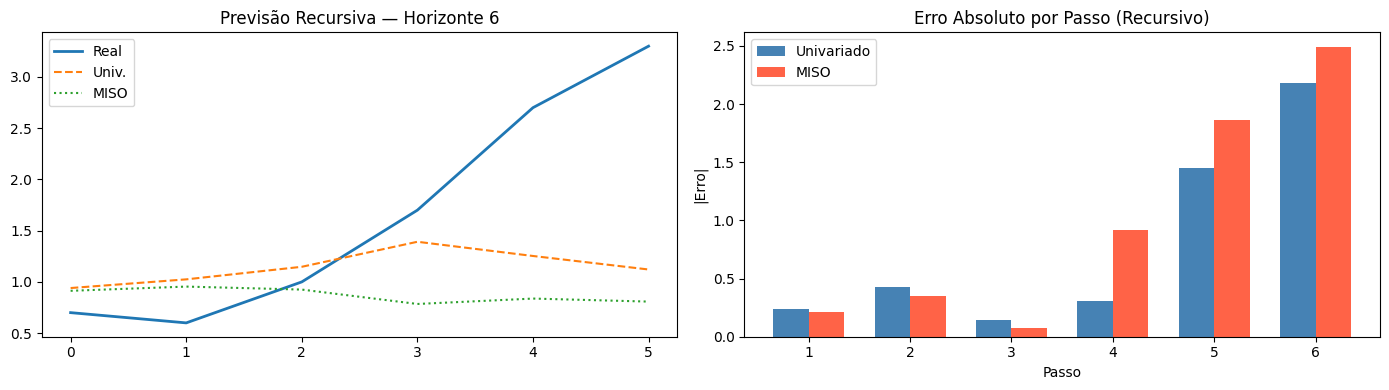

In [17]:
# --- Código fornecido: previsão recursiva ---
y_rec_uni  = recursive_forecast_univariate(
    model_uni, X_uni_te[0], horizon=HORIZON
)
y_rec_miso = recursive_forecast_multivariate(
    model_miso, X_miso_te[0], horizon=HORIZON,
    window_size=WINDOW_SIZE, n_features=n_features
)

y_true_h = y_uni_te[:HORIZON]

evaluate(y_true_h, y_rec_uni,  label='Recursivo Univariado', scaler=scaler, target_idx=target_idx)
evaluate(y_true_h, y_rec_miso, label='Recursivo MISO      ', scaler=scaler, target_idx=target_idx)

abs_uni  = np.abs(denorm(y_true_h) - denorm(y_rec_uni))
abs_miso = np.abs(denorm(y_true_h) - denorm(y_rec_miso))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(denorm(y_true_h), label='Real',      linewidth=2)
axes[0].plot(denorm(y_rec_uni),  label='Univ.',   linestyle='--')
axes[0].plot(denorm(y_rec_miso), label='MISO',    linestyle=':')
axes[0].set_title(f'Previsão Recursiva — Horizonte {HORIZON}')
axes[0].legend()

steps = np.arange(1, HORIZON + 1)
w = 0.35
axes[1].bar(steps - w/2, abs_uni,  w, label='Univariado', color='steelblue')
axes[1].bar(steps + w/2, abs_miso, w, label='MISO',       color='tomato')
axes[1].set_title('Erro Absoluto por Passo (Recursivo)')
axes[1].set_xlabel('Passo'); axes[1].set_ylabel('|Erro|')
axes[1].legend()
plt.tight_layout(); plt.show()

**Resposta Q5:**

**a) O erro aumenta ao longo do horizonte nos dois modelos? Este erro ocorre de forma semelhante?**
> No geral o erro tende a crescer à medida que avançamos no horizonte para ambos os modelos. Isso ocorre de forma semelhante em ambos porque o processo de realimentação faz com que pequenas imprecisões iniciais se acumulem.

> No gráfico, notamos que o Univariado começou com erros menores nos primeiros passos, e se manteve mais estável a longo prazo para este exemplo específico, mostrando que há uma diferença entre os dois modelos nos passos iniciais quando realizamos uma previsão recursiva.

**b) Por que a abordagem recursiva tende a degradar com o horizonte? O MISO atenua esse problema?**
> A degradação ocorre devido à **propagação de erro**: como o modelo usa suas próprias previsões anteriores (que contêm erros) como entrada para prever o próximo passo, o erro é incluído no sistema passo a passo, acumulando-se exponencialmente.

> O MISO pode atenuar esse problema se as variáveis exógenas (como T ou NOx) fornecerem um contexto que impeça a série de derivar muito do comportamento real, embora no modo puramente recursivo (onde as exógenas também precisariam ser previstas ou repetidas), essa atenuação dependa da qualidade da representação dessas variáveis.

**c) A comparação one-step vs. recursivo é justa? Justifique.**
> Não necessariamente. Em termos de uma comparação direta de qualidade de modelo, pode ser uma comparação injusta, isso porque há dificuldade maior associada ao método de previsão recursivo.

> A previsão one-step é mais simples, pois o modelo sempre tem acesso a dados reais e recentes. A previsão recursiva é uma tarefa muito mais complexa que testa a capacidade do modelo de capturar a dinâmica do sistema a longo prazo sem auxílio de dados externos reais durante o horizonte. Portanto, é esperado que as métricas (MSE/RMSE) sejam significativamente piores no modo recursivo do que no one-step.


---
### Q6 — Previsão Direta: MISO vs. MIMO

Aqui introduzimos o modelo **MIMO** (*Multiple Input, Multiple Output*): uma única rede que prevê simultaneamente os próximos `HORIZON` valores de **todas** as features. Vamos comparar com a abordagem recursiva MISO.

In [18]:
# --- Código fornecido: modelo MISO direto (multi-output para o target) ---
X_miso_ms, y_miso_ms = make_windows_multivariate(
    df_scaled, TARGET_COL, FEATURE_COLS, WINDOW_SIZE, horizon=HORIZON, mode='MISO'
)
X_miso_ms_tr, X_miso_ms_te = X_miso_ms[:split_mv], X_miso_ms[split_mv:]
y_miso_ms_tr, y_miso_ms_te = y_miso_ms[:split_mv], y_miso_ms[split_mv:]

loader_miso_ms = DataLoader(
    TimeSeriesDataset(X_miso_ms_tr, y_miso_ms_tr),
    batch_size=BATCH_SIZE, shuffle=False
)

# MISO direto: entrada multivariada, saída = HORIZON valores do target
model_miso_direct = MLP(
    n_input=WINDOW_SIZE * n_features,
    hidden_layers=[64, 32],
    n_output=HORIZON
)
print("=== MISO Direto (multi-step) ===")
train_model(model_miso_direct, loader_miso_ms, epochs=500, lr=1e-3, verbose=True)

=== MISO Direto (multi-step) ===
Época  100/500 | Perda: 0.004788
Época  200/500 | Perda: 0.004108
Época  300/500 | Perda: 0.003779
Época  400/500 | Perda: 0.003835
Época  500/500 | Perda: 0.003522


[0.017398620443672703,
 0.01178486472885457,
 0.010438570589897046,
 0.009649174006809185,
 0.00904424912397868,
 0.008455167677889149,
 0.008063560581210787,
 0.007779807656507252,
 0.007575010503633022,
 0.0074320514630969794,
 0.007311406768239399,
 0.007194861182633469,
 0.007085906689416521,
 0.0069817793085507765,
 0.006879173348438815,
 0.006798131883514875,
 0.006729299257419789,
 0.006654708649356118,
 0.006596576122406293,
 0.006535363129394624,
 0.006484525497875265,
 0.006430515119554623,
 0.006377040846841521,
 0.006332924158616354,
 0.006298402531048475,
 0.0062734990378163595,
 0.006213546357771736,
 0.006163264945263066,
 0.006121470797913231,
 0.006073737413056993,
 0.006043200221144602,
 0.00599216169997355,
 0.005939842186639979,
 0.005911768748427719,
 0.005877927905766271,
 0.005833911655899433,
 0.005799257341196708,
 0.005766130487793975,
 0.00573888405467317,
 0.005710249528910647,
 0.005681425257838176,
 0.005669065496592325,
 0.005632875136114539,
 0.005592736

In [19]:
# --- Código fornecido: modelo MIMO (prevê todas as features no horizonte) ---
loader_mimo_ms = DataLoader(
    TimeSeriesDataset(X_mimo_ms_tr, y_mimo_ms_tr),
    batch_size=BATCH_SIZE, shuffle=False
)

mimo_out_dim = HORIZON * n_features   # ex: 6 passos × 4 features = 24
model_mimo = MLP(
    n_input=WINDOW_SIZE * n_features,
    hidden_layers=[128, 64],
    n_output=mimo_out_dim
)
print("=== MIMO (multi-step, todas as features) ===")
train_model(model_mimo, loader_mimo_ms, epochs=500, lr=1e-3, verbose=True)

=== MIMO (multi-step, todas as features) ===
Época  100/500 | Perda: 0.004375
Época  200/500 | Perda: 0.003727
Época  300/500 | Perda: 0.003493
Época  400/500 | Perda: 0.003412
Época  500/500 | Perda: 0.003190


[0.019712807987594887,
 0.01292407466837811,
 0.011187128843702671,
 0.009867111754988039,
 0.009086407062741705,
 0.008532941788120845,
 0.008191891170720318,
 0.007905361911980435,
 0.0076463990964897215,
 0.007437989202102587,
 0.007273285540231015,
 0.007122918351789907,
 0.0069926862123547975,
 0.006858173045902587,
 0.0067449090646631606,
 0.0066341637561674275,
 0.006539405045923703,
 0.006446564816758924,
 0.006368979715579559,
 0.006295916464527152,
 0.006234803474471268,
 0.006182855979118142,
 0.00613594942242055,
 0.006078942021029809,
 0.006033811224384292,
 0.005993461130567575,
 0.005946193693301803,
 0.005887805594183091,
 0.005859490520032566,
 0.005825952267817532,
 0.005768830842238718,
 0.005725408680201139,
 0.00571424680224265,
 0.005667927935497747,
 0.005635885828976623,
 0.005592370879307892,
 0.005543939461137006,
 0.00549488630846128,
 0.0054697704192857065,
 0.005422378283655566,
 0.005405477490202184,
 0.005350357414932833,
 0.00531703506186161,
 0.00528641

[Recursivo MISO ]  MSE=1.7826  RMSE=1.3351  MAE=0.9854  SSE=10.70  MAPE=0.49  RRSE*:2.30
[MISO Direto    ]  MSE=1.8444  RMSE=1.3581  MAE=1.0492  SSE=11.07  MAPE=0.55  RRSE*:2.34
[MIMO (target)  ]  MSE=2.3737  RMSE=1.5407  MAE=1.4744  SSE=14.24  MAPE=1.10  RRSE*:2.66


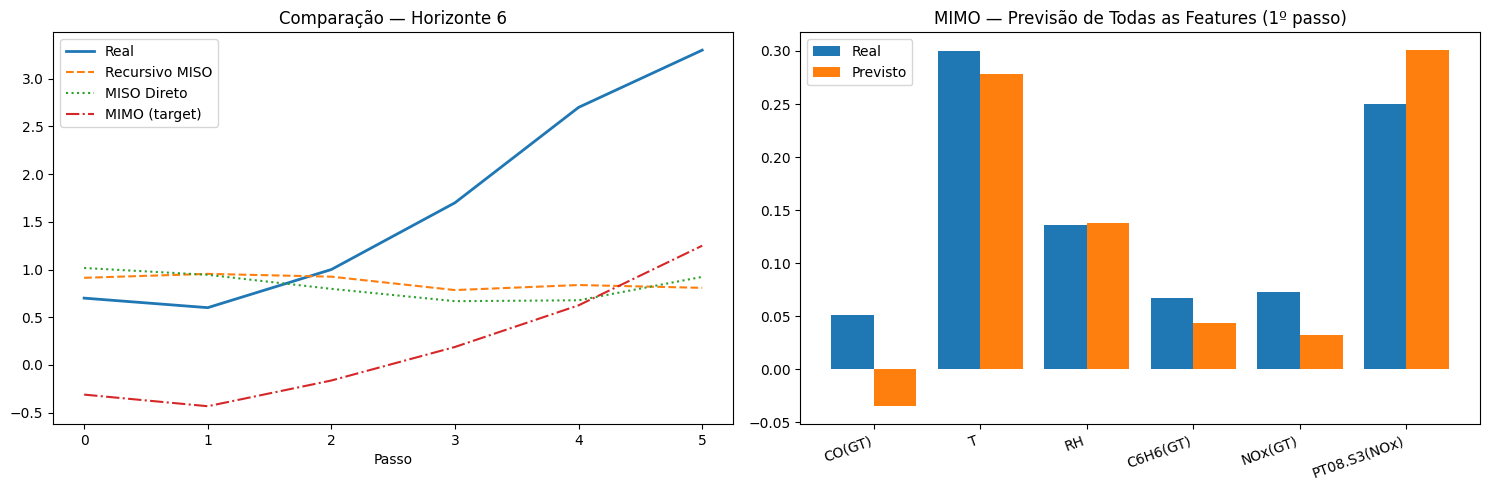

In [20]:
# MISO direto
yp_miso_dir = predict(model_miso_direct, X_miso_ms_te[:1]).ravel()  # (HORIZON,)

# MIMO: extrai apenas a coluna do target
yp_mimo_flat = predict(model_mimo, X_mimo_ms_te[:1]).ravel()  # (HORIZON * n_features,)
yp_mimo_all  = yp_mimo_flat.reshape(HORIZON, n_features)      # (HORIZON, n_features)
yp_mimo_tgt  = yp_mimo_all[:, target_idx]                     # (HORIZON,) — target

y_true_h = y_miso_ms_te[0]  # (HORIZON,)

evaluate(y_true_h, y_rec_miso,    label='Recursivo MISO ', scaler=scaler, target_idx=target_idx)
evaluate(y_true_h, yp_miso_dir,   label='MISO Direto    ', scaler=scaler, target_idx=target_idx)
evaluate(y_true_h, yp_mimo_tgt,   label='MIMO (target)  ', scaler=scaler, target_idx=target_idx)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(denorm(y_true_h),    label='Real',            linewidth=2)
axes[0].plot(denorm(y_rec_miso),  label='Recursivo MISO',  linestyle='--')
axes[0].plot(denorm(yp_miso_dir), label='MISO Direto',     linestyle=':')
axes[0].plot(denorm(yp_mimo_tgt), label='MIMO (target)',   linestyle='-.')
axes[0].set_title(f'Comparação — Horizonte {HORIZON}')
axes[0].legend(); axes[0].set_xlabel('Passo')

# MIMO: todas as variáveis previstas (1 passo além do horizonte)
axes[1].set_title('MIMO — Previsão de Todas as Features (1º passo)')
first_step_pred = yp_mimo_all[0]   # (n_features,)
first_step_true = y_mimo_ms_te[0, :n_features]  # (n_features,)
x_pos = np.arange(n_features)
axes[1].bar(x_pos - 0.2, first_step_true, 0.4, label='Real')
axes[1].bar(x_pos + 0.2, first_step_pred, 0.4, label='Previsto')
axes[1].set_xticks(x_pos); axes[1].set_xticklabels(FEATURE_COLS, rotation=20, ha='right')
axes[1].legend()

plt.tight_layout(); plt.show()

### Resposta Q6:

**a) Qual das três abordagens (recursiva, MISO direto, MIMO) apresentou previsões mais estáveis?**
> Com base nos resultados e nos gráficos de horizonte, as abordagens **MISO Recursivo** e **MISO Direto** apresentaram as previsões mais estáveis e precisas, com métricas de erro (MSE e RMSE) muito próximas entre si. Ambas conseguiram manter a trajetória da série de forma consistente ao longo dos 6 passos do horizonte.

> O modelo MIMO, embora tenha capturado a tendência de oscilação, apresentou um erro acumulado maior (MSE ≈ 2.37 vs ≈ 1.78 do MISO Recursivo), mostrando-se menos estável para a previsão específica do target neste experimento.

**b) Qual é a vantagem conceitual do MIMO em relação ao MISO, além de prever o target?**
> A principal vantagem conceitual do **MIMO** é a sua capacidade de capturar a **dinâmica conjunta** de todo o sistema. Enquanto o MISO foca exclusivamente na relação das entradas com um único alvo, o MIMO aprende as interdependências entre todas as variáveis exógenas simultaneamente. Isso permite que o modelo preserve a consistência entre as variáveis (por exemplo, a relação entre Temperatura, Umidade e Poluentes) ao longo do tempo, o que pode ser fundamental para evitar que as previsões de longo prazo se tornem incoerentes entre si.

---
# Seção 3 — Avaliação de Ajustes de Parâmetros

Os experimentos desta seção usam o modelo **MISO** como padrão (one-step), por ser o mais direto para isolar o efeito de cada hiperparâmetro. Quando relevante, a comparação com o univariado é indicada.

---
### Q7 — Arquitetura da Rede

Compare múltiplas arquiteturas de MLP no modo MISO. Identifique sinais de overfitting e underfitting.

Pequena  [16]                   MSE treino=0.00356  |  MSE teste=0.00262
Média    [64, 32]               MSE treino=0.00269  |  MSE teste=0.00357
Grande   [128, 64, 32]          MSE treino=0.00138  |  MSE teste=0.00367
Enorme   [256, 256]             MSE treino=0.00134  |  MSE teste=0.00437


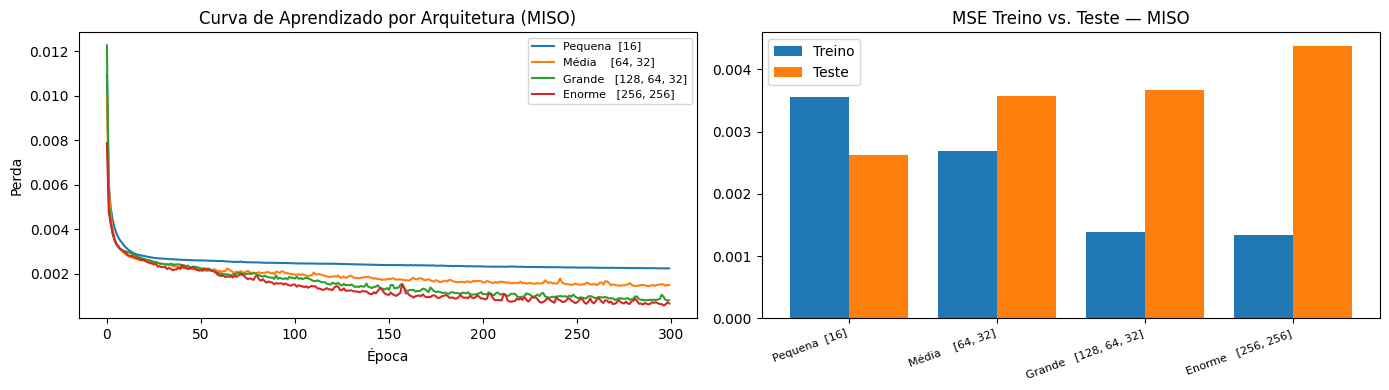

In [21]:
architectures = {
    'Pequena  [16]':          [16],
    'Média    [64, 32]':      [64, 32],
    'Grande   [128, 64, 32]': [128, 64, 32],
    'Enorme   [256, 256]':    [256, 256],
}

results_arch = {}
for name, layers in architectures.items():
    m = MLP(n_input=WINDOW_SIZE * n_features, hidden_layers=layers, n_output=1)
    h = train_model(m, loader_miso, epochs=300, lr=1e-3, verbose=False)
    mse_tr = mean_squared_error(y_miso_tr, predict(m, X_miso_tr))
    mse_te = mean_squared_error(y_miso_te, predict(m, X_miso_te))
    results_arch[name] = {'train': mse_tr, 'test': mse_te, 'history': h}
    print(f"{name:<30}  MSE treino={mse_tr:.5f}  |  MSE teste={mse_te:.5f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for name, res in results_arch.items():
    axes[0].plot(res['history'], label=name)
axes[0].set_title('Curva de Aprendizado por Arquitetura (MISO)')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Perda'); axes[0].legend(fontsize=8)

names = list(results_arch.keys())
x = np.arange(len(names))
axes[1].bar(x - 0.2, [results_arch[n]['train'] for n in names], 0.4, label='Treino')
axes[1].bar(x + 0.2, [results_arch[n]['test']  for n in names], 0.4, label='Teste')
axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=20, ha='right', fontsize=8)
axes[1].set_title('MSE Treino vs. Teste — MISO'); axes[1].legend()
plt.tight_layout(); plt.show()

**Resposta Q7:**

**a) Identifique sinais de overfitting e underfitting nos resultados.**

Primeiramente, vamos definir quando identificamos cada um dos sinais:
> **Underfitting** -> MSE Treino Alto + Teste Alto

> **Overfitting** -> MSE Treino baixo + Teste Muito Alto

> **Ideal** -> MSE Treino ~ Teste, ambos baixos

> Com base nos resultados:

> **Arquitetura Pequena [16]:** Apresentou o melhor equilíbrio e a melhor generalização, com o menor MSE de teste (0.00262). É o cenário mais próximo do **Ideal**.

> **Arquiteturas Média, Grande e Enorme:** Apresentam sinais de **Overfitting**. Observe que conforme aumentamos a complexidade, o MSE de treino cai consideravelmente (de 0.00356 para 0.00134), mas o MSE de teste sobe (de 0.00262 para 0.00437). Isso indica que as redes maiores estão 'memorizando' o ruído dos dados de treino (especialmente as variáveis exógenas) em vez de aprender a dinâmica geral.

> **Underfitting:** Não foi observado de forma significativa, já que mesmo a rede pequena conseguiu uma perda de treino bastante baixa.

**b) A arquitetura com melhor equilíbrio para o MISO é maior ou menor do que você esperaria para o univariado?**
> Espera-se que o MISO exija uma arquitetura com mecanismos de regularização melhores ou com menor complexidade relativa (comparada ao número de entradas) do que o univariado.

> Isso ocorre porque o MISO tem uma dimensão de entrada 6x maior (72 entradas contra 12 do univariado). Com tantas variáveis de entrada, o risco de a rede encontrar correlações equivocadas aumenta. Por isso, uma arquitetura 'Pequena' acaba performando melhor no MISO por atuar como um filtro natural, evitando que o modelo se perca na complexidade das variáveis exógenas, enquanto no univariado uma rede 'Média' poderia ser necessária para extrair padrões mais profundos de uma única variável.


---
### Q8 — Tamanho da Janela

Avalie o impacto do `WINDOW_SIZE` no MISO, considerando tanto o erro one-step quanto a estabilidade da previsão recursiva.

ws=  4  MSE one-step=0.00316  |  MSE recursivo=0.00349
ws=  8  MSE one-step=0.00315  |  MSE recursivo=0.00744
ws= 12  MSE one-step=0.00348  |  MSE recursivo=0.00757
ws= 24  MSE one-step=0.00379  |  MSE recursivo=0.00464


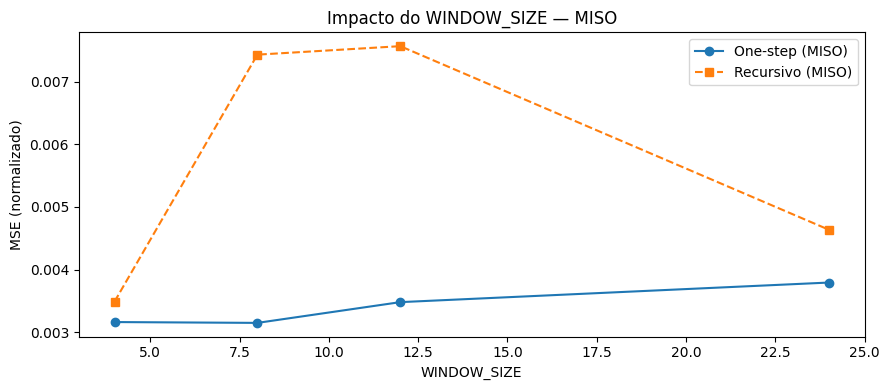

In [22]:
# --- Código fornecido ---
window_sizes = [4, 8, 12, 24]
results_win  = {}

for ws in window_sizes:
    Xw, yw = make_windows_multivariate(
        df_scaled, TARGET_COL, FEATURE_COLS, ws, horizon=1, mode='MISO'
    )
    sp = n_train - ws
    Xw_tr, Xw_te = Xw[:sp], Xw[sp:]
    yw_tr, yw_te = yw[:sp], yw[sp:]

    ld = DataLoader(TimeSeriesDataset(Xw_tr, yw_tr), batch_size=BATCH_SIZE, shuffle=False)
    mw = MLP(n_input=ws * n_features, hidden_layers=[64, 32], n_output=1)
    train_model(mw, ld, epochs=300, lr=1e-3, verbose=False)

    mse_1 = mean_squared_error(yw_te, predict(mw, Xw_te))
    y_rec = recursive_forecast_multivariate(mw, Xw_te[0], HORIZON, ws, n_features)
    mse_r = mean_squared_error(yw_te[:HORIZON], y_rec)
    results_win[ws] = {'1step': mse_1, 'recursive': mse_r}
    print(f"ws={ws:3d}  MSE one-step={mse_1:.5f}  |  MSE recursivo={mse_r:.5f}")

fig, ax = plt.subplots(figsize=(9, 4))
ws_vals = list(results_win.keys())
ax.plot(ws_vals, [results_win[w]['1step']     for w in ws_vals], 'o-',  label='One-step (MISO)')
ax.plot(ws_vals, [results_win[w]['recursive'] for w in ws_vals], 's--', label='Recursivo (MISO)')
ax.set_title('Impacto do WINDOW_SIZE — MISO')
ax.set_xlabel('WINDOW_SIZE'); ax.set_ylabel('MSE (normalizado)')
ax.legend(); plt.tight_layout(); plt.show()

**Resposta Q8:**

**a) Como o WINDOW_SIZE afeta o erro one-step no MISO?**
> O `WINDOW_SIZE` afeta minimamente o erro *one-step* porque, para prever apenas um passo à frente, os lags mais imediatos costumam ser mais relevantes como vimos anteriormente na Q2. Como o modelo MISO já possui várias variáveis de entrada, aumentar a janela de 4 para 24 se adiciona pouco em termos estatísticos que o modelo já não tenha capturado com uma janela curta. O leve aumento no MSE (de 0.0031 para 0.0037) sugere inclusive um princípio de overfitting ou dificuldade de otimização ao lidar com vetores de entrada muito longos (24 * 6 = 144 entradas).

**b) O efeito sobre o erro recursivo é diferente? Por quê pode ser diferente do caso univariado?**
> Sim, o efeito é bem diferente e não linear. Enquanto no *one-step* o erro é estável, no recursivo observamos que janelas intermediárias (8 e 12) performaram pior do que a janela curta (4) ou a janela longa (24).

> No caso univariado, uma janela maior costuma ajudar a estabilizar a recursão pois oferece mais contexto histórico. No **MISO**, existe o desafio da **estabilidade das variáveis exógenas**: na nossa implementação recursiva, assumimos que as variáveis exógenas permanecem constantes ou seguem o último valor. Se a janela é muito grande, o modelo pode tentar encontrar padrões em dependências temporais longas que, ao serem alimentadas com previsões que propagam erro, caem mais rápido.

> A janela 24 apresentou uma melhora na estabilidade recursiva em relação à 12, sugerindo que ela pode ter capturado a sazonalidade diária apresentada na Q2 (onde o lag 24 sugeria uma dependência) que ajuda o modelo a não desviar tanto do valor real durante os 6 passos à frente.


---
### Q9 — Função de Perda

Compare os modelos MISO treinados com MSE, MAE e SSE. Avalie com as três métricas.

In [23]:
# --- Código fornecido ---
class SSELoss(nn.Module):
    def forward(self, pred, target): return torch.sum((pred - target) ** 2)

loss_fns = {'MSELoss': nn.MSELoss(), 'MAELoss': nn.L1Loss(), 'SSELoss': SSELoss()}
results_loss = {}

for lname, lfn in loss_fns.items():
    m = MLP(n_input=WINDOW_SIZE * n_features, hidden_layers=[64, 32], n_output=1)
    train_model(m, loader_miso, epochs=300, lr=1e-3, loss_fn=lfn, verbose=False)
    mse, rmse, mae, sse = evaluate(
        y_miso_te, predict(m, X_miso_te),
        label=f'MISO + {lname}', scaler=scaler, target_idx=target_idx
    )
    results_loss[lname] = {'mse': mse, 'rmse': rmse, 'mae': mae, 'sse': sse}

[MISO + MSELoss]  MSE=0.4287  RMSE=0.6547  MAE=0.4646  SSE=608.72  MAPE=0.31  RRSE*:0.86
[MISO + MAELoss]  MSE=0.4352  RMSE=0.6597  MAE=0.4153  SSE=617.98  MAPE=0.23  RRSE*:0.87
[MISO + SSELoss]  MSE=0.4001  RMSE=0.6326  MAE=0.4184  SSE=568.17  MAPE=0.24  RRSE*:0.83


**Resposta Q14:**

**a) Qual função de perda apresentou melhor desempenho nas métricas? Este achado faz sentido?**
> A função **SSELoss** apresentou o melhor desempenho geral, obtendo o menor `MSE = 0.4001` e `RMSE = 0.6326` no conjunto de teste.

> Faz sentido porque o SSE, matematicamente, é uma escala da MSE. Ao não dividir pela quantidade de amostras no cálculo da perda (loss), o gradiente resultante é maior, o que pode ajudar o otimizador a escapar de mínimos locais e convergir para uma solução mais precisa em datasets ruidosos como o de qualidade do ar. Além disso, como o SSE eleva o erro ao quadrado, ele penaliza os **outliers** e os picos, forçando o modelo a se ajustar melhor a eventos críticos, como os picos de poluição.

**b) Em quais situações cada função parece mais adequada para séries temporais?**
> **MSE / SSE:** São adequadas quando erros grandes ao longo da série são intoleráveis ou quando não apresenta outliers extremos. Em séries temporais de poluição, errar um pico de CO é mais grave do que errar pequenas oscilações na base; por isso, o foco no quadrado do erro é preferível.
A grande diferença está no tamanho dos batches. Para batches de tamanho variável, o SSE apresenta instabilidade, então é preferível utilizar o MSE.

> **MAE (Erro Absoluto):** É mais adequada quando os dados possuem muitos erros de medição ou outliers, que não devem distorcer o aprendizado do modelo. O MAE é mais robusto, pois trata todos os erros linearmente, resultando em um modelo que foca na tendência média da série.

---
### Q10 — Sensibilidade a Hiperparâmetros

Avalie o impacto de pequenas mudanças nos hiperparâmetros do modelo MISO.

In [24]:
grid = [
    {'neurons': 16,  'epochs': 200, 'lr': 1e-3},
    {'neurons': 64,  'epochs': 200, 'lr': 1e-3},
    {'neurons': 64,  'epochs': 500, 'lr': 1e-3},
    {'neurons': 64,  'epochs': 200, 'lr': 1e-2},
    {'neurons': 128, 'epochs': 200, 'lr': 1e-3},
    {'neurons': 128, 'epochs': 500, 'lr': 1e-4},
]

hp_results = []
for cfg in grid:
    m = MLP(n_input=WINDOW_SIZE * n_features, hidden_layers=[cfg['neurons']], n_output=1)
    train_model(m, loader_miso, epochs=cfg['epochs'], lr=cfg['lr'], verbose=False)
    mse_te = mean_squared_error(y_miso_te, predict(m, X_miso_te))
    hp_results.append({**cfg, 'test_mse': mse_te})
    print(f"neurons={cfg['neurons']:3d}  epochs={cfg['epochs']:4d}  lr={cfg['lr']}  →  MSE={mse_te:.5f}")

print("\n", pd.DataFrame(hp_results).sort_values('test_mse').to_string(index=False))

neurons= 16  epochs= 200  lr=0.001  →  MSE=0.00223
neurons= 64  epochs= 200  lr=0.001  →  MSE=0.00268
neurons= 64  epochs= 500  lr=0.001  →  MSE=0.00337
neurons= 64  epochs= 200  lr=0.01  →  MSE=0.00403
neurons=128  epochs= 200  lr=0.001  →  MSE=0.00307
neurons=128  epochs= 500  lr=0.0001  →  MSE=0.00282

  neurons  epochs     lr  test_mse
      16     200 0.0010  0.002226
      64     200 0.0010  0.002683
     128     500 0.0001  0.002818
     128     200 0.0010  0.003070
      64     500 0.0010  0.003369
      64     200 0.0100  0.004028


### Resposta Q10:

**a) Quais hiperparâmetros causaram maiores mudanças no desempenho do modelo MISO? A sensibilidade é diferente do que você observaria num modelo univariado?**

> Com base nos resultados, a **Taxa de Aprendizado (LR)** foi o hiperparâmetro mais sensível. Quando a LR foi aumentada para `0.01`, o erro de teste subiu drasticamente para `0.0040` versus `0.0027` no cenário de 64 neurônios e 200 épocas, indicando que o modelo teve dificuldade em convergir em uma superfície de erro mais complexa. O impacto do número de épocas também ocorre mas de maneira secundária. Em um cenário com poucas épocas, o modelo pode não convergir, enquanto esticar a quantidade de épocas pode não gerar ganhos adicionais.

> A sensibilidade no MISO é significativamente **maior** do que no univariado. Isso ocorre porque o vetor de entrada no MISO é muito maior (WINDOW_SIZE × n_features), o que resulta em um número muito mais elevado de pesos na primeira camada da rede. Com mais parâmetros para ajustar, pequenos desequilíbrios na LR podem fazer com que o otimizador ignore padrões sutis ou foque excessivamente em ruídos das variáveis exógenas.

> Além disso, o número de **épocas** torna-se mais crítico no MISO: como o modelo tem maior capacidade de memorização, treinar por muitas épocas (500 vs 200) com uma arquitetura larga e LR padrão tende a aumentar o erro de teste, evidenciando o *overfitting* que é menos pronunciado em modelos univariados mais simples.

---
# Seção 4 — Avaliação Aprofundada de Séries Temporais

---
### Q11 — Por que não usar shuffle?

O código abaixo treina dois modelos MISO idênticos, sendo um com `shuffle=True`, outro com `shuffle=False`. O objetivo é comparar o desempenho.

shuffle=True
shuffle=False
[MISO shuffle=True ]  MSE=0.3925  RMSE=0.6265  MAE=0.4270  SSE=557.39  MAPE=0.29  RRSE*:0.83
[MISO shuffle=False]  MSE=0.4259  RMSE=0.6526  MAE=0.4346  SSE=604.75  MAPE=0.25  RRSE*:0.86


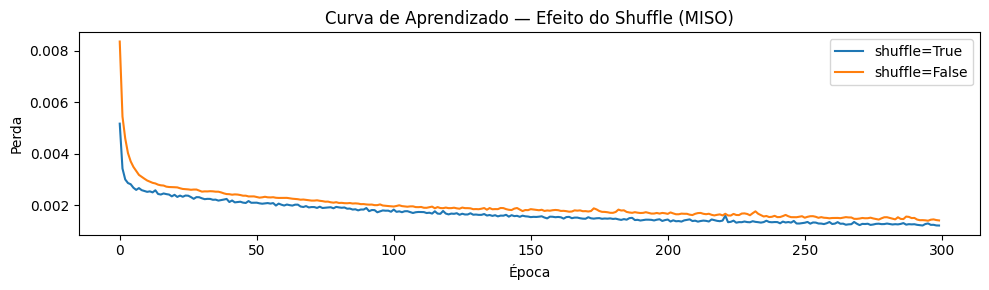

In [25]:
ds_miso = TimeSeriesDataset(X_miso_tr, y_miso_tr)
ld_shuf = DataLoader(ds_miso, batch_size=BATCH_SIZE, shuffle=True)
ld_nosh = DataLoader(ds_miso, batch_size=BATCH_SIZE, shuffle=False)

m_shuf = MLP(n_input=WINDOW_SIZE * n_features, hidden_layers=[64, 32], n_output=1)
m_nosh = MLP(n_input=WINDOW_SIZE * n_features, hidden_layers=[64, 32], n_output=1)
m_nosh.load_state_dict(m_shuf.state_dict())   # mesmos pesos iniciais

print("shuffle=True")
h_shuf = train_model(m_shuf, ld_shuf, epochs=300, lr=1e-3, verbose=False)
print("shuffle=False")
h_nosh = train_model(m_nosh, ld_nosh, epochs=300, lr=1e-3, verbose=False)

evaluate(y_miso_te, predict(m_shuf, X_miso_te), label='MISO shuffle=True ', scaler=scaler, target_idx=target_idx)
evaluate(y_miso_te, predict(m_nosh, X_miso_te), label='MISO shuffle=False', scaler=scaler, target_idx=target_idx)

plt.figure(figsize=(10, 3))
plt.plot(h_shuf, label='shuffle=True')
plt.plot(h_nosh, label='shuffle=False')
plt.title('Curva de Aprendizado — Efeito do Shuffle (MISO)')
plt.xlabel('Época'); plt.ylabel('Perda'); plt.legend()
plt.tight_layout(); plt.show()

### Resposta Q11:

**Por que embaralhar os dados é problemático para séries temporais, mesmo no modo MISO? O experimento acima confirma ou contraria essa intuição?**

> O uso de `shuffle=True` é problemático em séries temporais porque desfaz a continuidade cronológica necessária para capturar padrões de dependência temporal, como tendências, sazonalidades e ciclos. No contexto de séries como a de qualidade do ar, a ordem dos dados é informativa: picos de poluição seguem uma lógica diária. Ao embaralhar, o modelo deixa de aprender a transição natural entre estados (ex: a dissipação gradual de gases) e passa a tratar cada janela como um evento isolado e independente, o que prejudica a capacidade de generalização para cenários futuros onde a sequência cronológica é fundamental.

> No entanto, o experimento acima contraria essa intuição teórica, pois o modelo com `shuffle=True` apresentou métricas ligeiramente superiores (`MSE=0.3925` vs `MSE=0.4259`). Isso ocorre frequentemente em redes neurais porque o embaralhamento ajuda o otimizador a evitar mínimos locais e reduz a correlação entre gradientes de batches consecutivos, acelerando a convergência. Apesar do ganho numérico neste teste específico, o uso de shuffle continua sendo uma prática não recomendada para séries temporais, pois pode criar um viés de otimização que não se sustenta em previsões de longo prazo ou em horizontes recursivos onde a coerência temporal é testada ao limite.

---
### Q12 — Diferenciação da Série

O código aplica diferenciação de 1ª ordem **apenas à variável target** antes de construir as janelas MISO. Compare com o modelo treinado na série original.

=== MISO + série diferenciada ===
Época  100/500 | Perda: 0.001608
Época  200/500 | Perda: 0.001304
Época  300/500 | Perda: 0.001114
Época  400/500 | Perda: 0.000975
Época  500/500 | Perda: 0.001018

MSE MISO original     : 0.00313
MSE MISO diferenciado : 0.00308


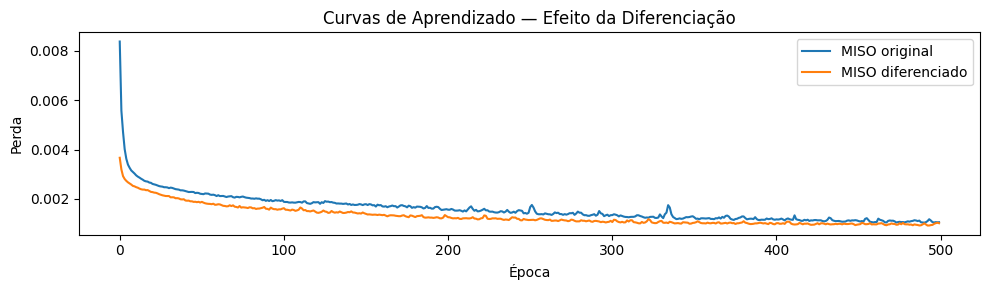

In [26]:
# --- Código fornecido ---
df_diff = df_scaled.copy()
df_diff[TARGET_COL] = df_diff[TARGET_COL].diff().fillna(0)

Xd, yd = make_windows_multivariate(
    df_diff, TARGET_COL, FEATURE_COLS, WINDOW_SIZE, horizon=1, mode='MISO'
)
Xd_tr, Xd_te = Xd[:split_mv], Xd[split_mv:]
yd_tr, yd_te = yd[:split_mv], yd[split_mv:]

ld_diff = DataLoader(TimeSeriesDataset(Xd_tr, yd_tr), batch_size=BATCH_SIZE, shuffle=False)
m_diff  = MLP(n_input=WINDOW_SIZE * n_features, hidden_layers=[64, 32], n_output=1)

print("=== MISO + série diferenciada ===")
hist_diff = train_model(m_diff, ld_diff, epochs=500, lr=1e-3, verbose=True)

mse_orig = mean_squared_error(y_miso_te, predict(model_miso, X_miso_te))
mse_diff = mean_squared_error(yd_te,     predict(m_diff,     Xd_te))
print(f"\nMSE MISO original     : {mse_orig:.5f}")
print(f"MSE MISO diferenciado : {mse_diff:.5f}")

plt.figure(figsize=(10, 3))
plt.plot(hist_miso[:500], label='MISO original')
plt.plot(hist_diff,       label='MISO diferenciado')
plt.title('Curvas de Aprendizado — Efeito da Diferenciação')
plt.xlabel('Época'); plt.ylabel('Perda'); plt.legend()
plt.tight_layout(); plt.show()

**Resposta Q12:**

**a) Qual modelo generaliza melhor: MISO na série original ou na diferenciada?**
> O modelo na **série diferenciada** apresentou uma capacidade de generalização ligeiramente superior, com um MSE de teste de `0.00308` contra `0.00313` do modelo original. A diferenciação auxilia na estacionarização da série ao remover componentes como variações na média local, permitindo que a MLP foque no aprendizado das mudanças de estado em vez de valores absolutos, o que frequentemente resulta em um erro menor e curvas de aprendizado mais estáveis. Não é indicado diferenciar séries que já são estacionárias. Para avaliar se uma série é ou não estacionária, alguns testes, como o KPSS (Kwiatkowski-Phillips-Schmidt-Shin) auxiliam estatisticamente o modelo.

**b) A diferenciação afeta igualmente todos os modelos (univariado, MISO, MIMO)?**
> Não. No modelo **univariado**, a diferenciação é crucial em caso de não-estacionariedade, porque a rede tem apenas o histórico de uma variável para identificar padrões e remover a tendência facilita muito o trabalho. No **MISO**, o efeito pode ser menor, pois as variáveis exógenas já fornecem pistas sobre o contexto (ex: se NOx sobe, CO provavelmente subirá), compensando parte da não-estacionariedade. No **MIMO**, o desafio aumenta, pois se diferenciarmos todas as variáveis, a rede precisa aprender a correlação entre as *mudanças* de todas as features simultaneamente, o que pode tornar o treinamento mais ruidoso se a relação entre os incrementos for menos clara que a relação entre os níveis originais.


---
### Q13 — Média Móvel como Pré-processamento

A média móvel é aplicada **apenas ao target** antes de construir as janelas. As features exógenas permanecem sem suavização. Compare com o MISO original.

=== MISO + média móvel ===
Época  100/500 | Perda: 0.000162
Época  200/500 | Perda: 0.000142
Época  300/500 | Perda: 0.000116
Época  400/500 | Perda: 0.000108
Época  500/500 | Perda: 0.000090

MSE MISO sem pré-proc. : 0.00313
MSE MISO + média móvel : 0.00017


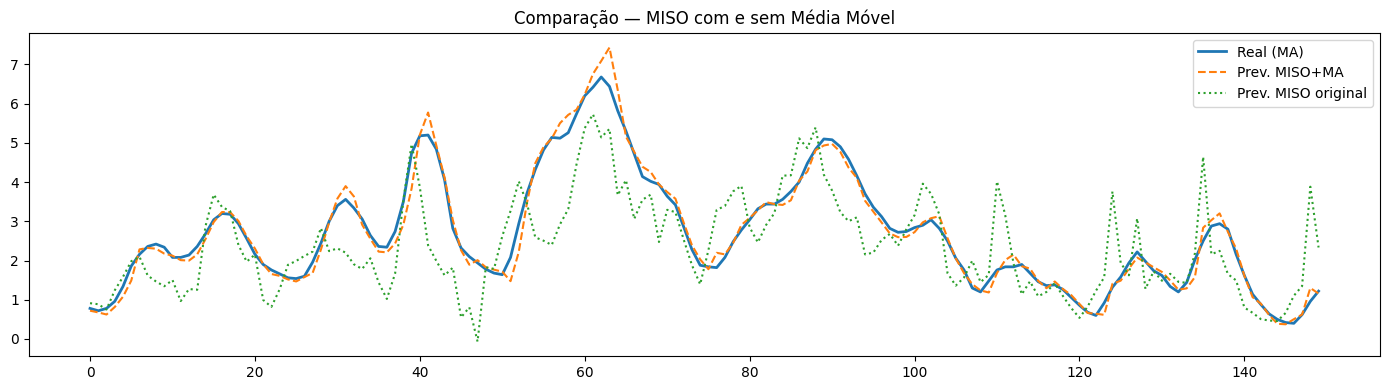

In [27]:
# --- Código fornecido ---
MA_WIN = 5
df_ma  = df_scaled.copy()
df_ma[TARGET_COL] = df_ma[TARGET_COL].rolling(MA_WIN, min_periods=1).mean()

Xma, yma = make_windows_multivariate(
    df_ma, TARGET_COL, FEATURE_COLS, WINDOW_SIZE, horizon=1, mode='MISO'
)
Xma_tr, Xma_te = Xma[:split_mv], Xma[split_mv:]
yma_tr, yma_te = yma[:split_mv], yma[split_mv:]

ld_ma = DataLoader(TimeSeriesDataset(Xma_tr, yma_tr), batch_size=BATCH_SIZE, shuffle=False)
m_ma  = MLP(n_input=WINDOW_SIZE * n_features, hidden_layers=[64, 32], n_output=1)

print("=== MISO + média móvel ===")
train_model(m_ma, ld_ma, epochs=500, lr=1e-3, verbose=True)

mse_ma   = mean_squared_error(yma_te,    predict(m_ma,     Xma_te))
mse_base = mean_squared_error(y_miso_te, predict(model_miso, X_miso_te))

print(f"\nMSE MISO sem pré-proc. : {mse_base:.5f}")
print(f"MSE MISO + média móvel : {mse_ma:.5f}")

N_plot = min(150, len(yma_te))
plt.figure(figsize=(14, 4))
plt.plot(denorm(yma_te[:N_plot]),               label='Real (MA)',       linewidth=2)
plt.plot(denorm(predict(m_ma, Xma_te)[:N_plot]),label='Prev. MISO+MA',  linestyle='--')
plt.plot(denorm(predict(model_miso, X_miso_te)[:N_plot]),
         label='Prev. MISO original', linestyle=':')
plt.title('Comparação — MISO com e sem Média Móvel')
plt.legend(); plt.tight_layout(); plt.show()

**Resposta Q13:**

**a) O pré-processamento por média móvel surtiu efeito positivo no MISO?**
> Pelo MSE obtido em ambos os casos, o pré-processamento surtiu efeito bem positivo, com `MSE < 0.001` vs `MSE = 0.003`. Isso ocorre pois a média móvel transformou um problema de 'prever o a alta variabilidade de curto prazo' em um problema de 'prever a tendência de médio prazo', que é matematicamente muito mais simples para uma MLP, visto que há um Aumento da Relação Sinal-Ruído, estabilidade do gradiente e redução da variância do target.

**b) Faz sentido suavizar apenas o target e manter as exógenas brutas? Quais são os prós e contras?**
> Sim, faz sentido em cenários onde o objetivo é prever a tendência estrutural da série, removendo ruídos de alta frequência que podem confundir o gradiente da rede neural.

> **Prós:**
> 1. **Redução de Ruído no Gradiente:** Ao suavizar o target, eliminamos variações que a rede tentaria decorar, facilitando a convergência para um padrão mais estável.
> 2. **Preservação da Reatividade:** Manter as exógenas brutas permite que o modelo ainda receba sinais imediatos de mudanças bruscas no ambiente (ex: um aumento repentino no tráfego ou mudança de temperatura) que precedem a mudança na tendência do CO.
> 3. **Melhoria nas Métricas:** Como visto no MSE, o erro cai drasticamente porque o modelo foca no componente de baixa frequência, que é inerentemente mais previsível.

> **Contras:**
> 1. **Lag de Fase:** Médias móveis introduzem um atraso temporal na série. O modelo pode aprender a prever um valor que, na vida real, já aconteceu há alguns passos.
> 2. **Subestimação de Picos:** Se o objetivo for detectar alertas de poluição extrema (outliers reais), a suavização esconde esses eventos, tornando o modelo otimista demais ou lento para reagir a emergências reais.
> 3. **Desalinhamento Causal:** Existe o risco de criar um descasamento temporal entre uma causa abrupta na variável exógena e o efeito suavizado no target.


---
### Q14 — Análise Temporal do Erro

Analise os resíduos ao longo do tempo para o modelo MISO. Verifique se o erro é constante ou apresenta padrões sistemáticos.

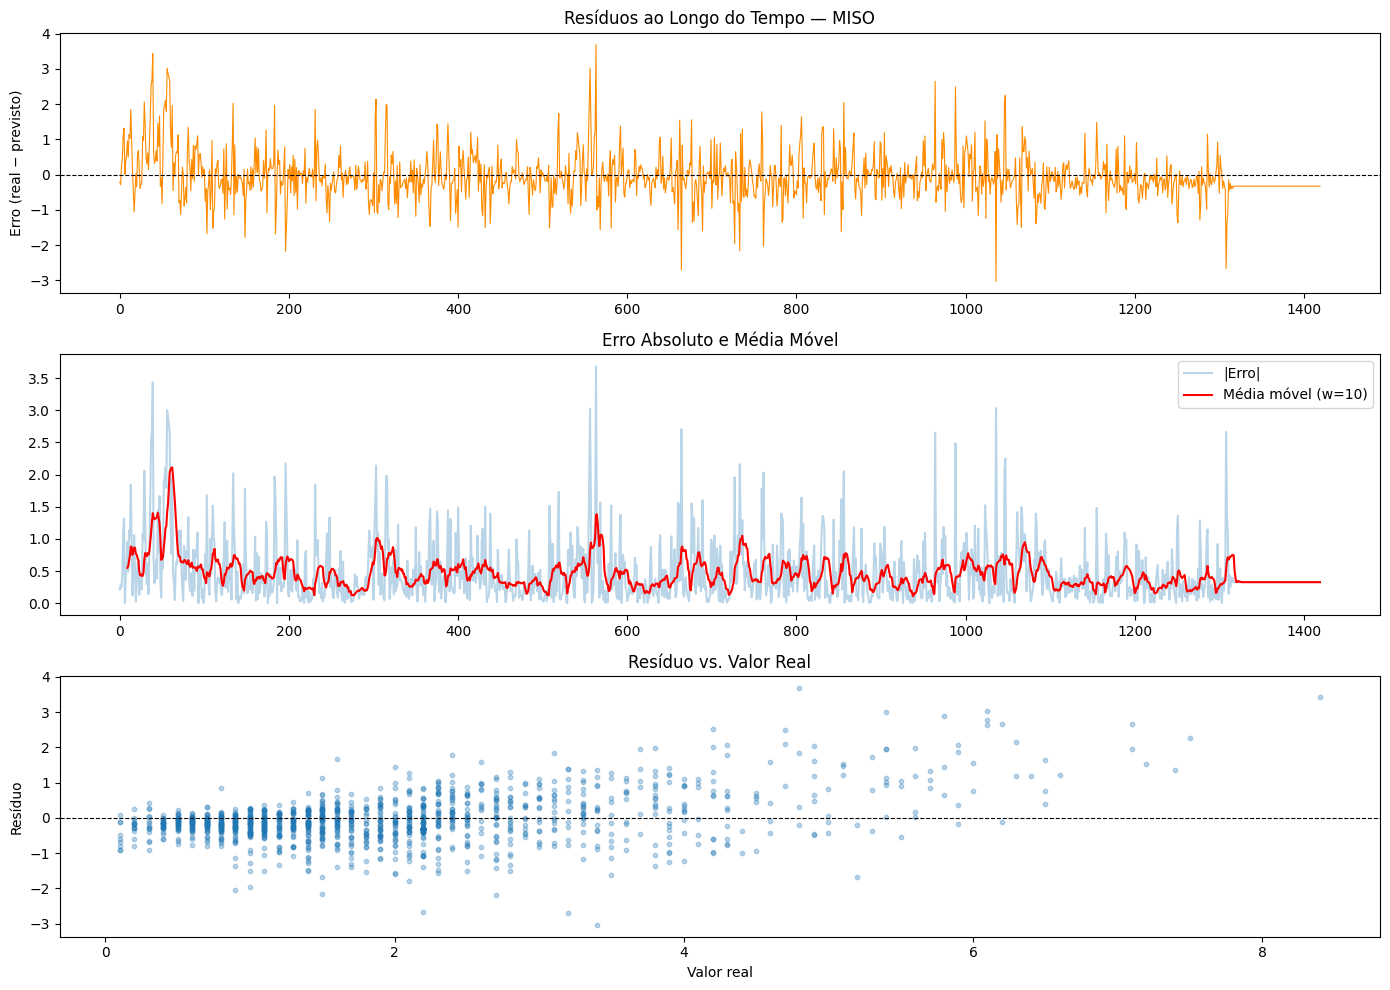

Média dos resíduos : -0.0517
Desvio dos resíduos: 0.6585
Maior erro absoluto: 3.6841 (índice 563)


In [28]:
# --- Código fornecido ---
yp_miso_full = predict(model_miso, X_miso_te)

yt_orig = denorm(y_miso_te)
yp_orig = denorm(yp_miso_full)
residuals  = yt_orig - yp_orig
abs_errors = np.abs(residuals)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(residuals, color='darkorange', linewidth=0.8)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Resíduos ao Longo do Tempo — MISO', fontsize=12)
axes[0].set_ylabel('Erro (real − previsto)')

roll_e = pd.Series(abs_errors).rolling(10).mean()
axes[1].plot(abs_errors, alpha=0.3, label='|Erro|')
axes[1].plot(roll_e,     color='red', label='Média móvel (w=10)')
axes[1].set_title('Erro Absoluto e Média Móvel', fontsize=12)
axes[1].legend()

axes[2].scatter(yt_orig, residuals, alpha=0.3, s=10)
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_title('Resíduo vs. Valor Real', fontsize=12)
axes[2].set_xlabel('Valor real'); axes[2].set_ylabel('Resíduo')

plt.tight_layout(); plt.show()

print(f"Média dos resíduos : {residuals.mean():.4f}")
print(f"Desvio dos resíduos: {residuals.std():.4f}")
print(f"Maior erro absoluto: {abs_errors.max():.4f} (índice {abs_errors.argmax()})")

 **Resposta Q14:**

**a) O erro do MISO é constante ao longo do tempo?**
> Não. Ao observar o primeiro gráfico (Resíduos ao Longo do Tempo) e a média móvel do erro absoluto, nota-se que o erro oscila significativamente, além disso, o desvio padrão dos resíduos de `0.66` indica uma variabilidade alta para o padrão dos dados. Existem períodos de relativa estabilidade onde o erro é próximo de zero, que são justamente os períodos de baixa da emissão como madrugada e fins de semana, e momentos de pico do erro, que observamos ser as transições abruptas que o modelo tem dificuldade em prever. Isso indica que a capacidade preditiva do modelo varia dependendo da dinâmica atual da série, não sendo um ruído branco constante.

**b) Existem regiões de falha sistemática? Compare com o que você observaria no modelo univariado.**
> Sim. As falhas sistemáticas ocorrem principalmente nos picos de concentração de CO. O modelo apresenta um 'atraso' ou uma tendência de subestimar valores muito altos. Comparado ao modelo univariado, o MISO pode ser levemente mais estável em transições suaves devido ao contexto das variáveis exógenas (como NOx e C6H6), mas ambos compartilham a dificuldade estrutural de prever mudanças abruptas que não foram precedidas por um sinal claro na janela de histórico.

**c) O gráfico de resíduo vs. valor real revela algum padrão (heteroscedasticidade, viés)?**
> Sim, revela um padrão claro de **heterocedasticidade**. No terceiro gráfico, nota-se que conforme o 'Valor Real' aumenta no eixo X, a dispersão dos resíduos no eixo Y também aumenta. Isso significa que a incerteza do modelo cresce em episódios de alta poluição. Além disso, há um leve viés negativo para valores altos, confirmando que o modelo tende a ser conservador e subestimar os níveis críticos de poluição e atrapalha o controle de emissão de CO.

---
### Q15 — Limitações do MLP para Séries Temporais

Com base em todos os experimentos realizados, reflita sobre as limitações do MLP, tanto na versão univariada quanto nas versões MISO e MIMO.

**Resposta Q15:**

**a) Quais são as principais limitações do MLP no contexto de séries temporais univariadas?**
> A principal limitação é a **falta de memória interna**. Como o MLP trata cada janela como um vetor estático (independente), ele não compreende a continuidade temporal de forma intrínseca. Além disso, as MLPs tendem a ser 'suavizadoras', apresentando grande dificuldade em prever picos e vales abruptos, geralmente entregando uma previsão que é apenas uma média ponderada dos lags passados, resultando em um atraso sistemático na detecção de mudanças de tendência.

**b) O uso de features exógenas (MISO) resolve alguma dessas limitações? Quais permanecem?**
> O MISO ajuda a reduzir a incerteza ao fornecer **contexto**. Por exemplo, saber que o NOx subiu ajuda a prever que o CO também subirá, mesmo que o histórico do CO ainda não mostre isso. No entanto, a limitação de 'suavização' e a falta de memória persistem. Além disso, o MISO introduz a **uma alta dimensionalidade**: com muitas entradas, a rede torna-se muito mais sensível a hiperparâmetros e propensa ao overfitting em ruídos das variáveis secundárias.

**c) A abordagem MIMO apresenta limitações específicas que o MISO não tem?**
> Sim. O MIMO exige que a rede aprenda uma função muito mais complexa, pois deve mapear o passado para a **dinâmica conjunta** de todas as séries. Isso pode diluir o aprendizado do target principal (como vimos no MSE maior do MIMO para o CO). Outra limitação é a rigidez do horizonte: se o modelo foi treinado para 6 passos, ele não consegue prever 7 sem ser redefinido, ao contrário do recursivo.

**d) Em quais situações o MLP (nas três variantes) não é adequado? Que arquiteturas seriam mais apropriadas?**
> A MLP não é adequada para séries com **dependências de longuíssimo prazo** (onde o que aconteceu há 100 passos ainda importa) ou séries com padrões temporais muito dinâmicos. Em situações que exigem capturar a sequência lógica e temporal, arquiteturas como **LSTMs (Long Short-Term Memory)** são mais apropriadas por possuirem portões de memória. Para capturar relações globais em séries muito longas, o **Transformer** (com mecanismos de atenção) tem se mostrado superior.